# Deep Learning Workshop — Notebook 1 of 2
## Foundations: Neural Networks, Training Mechanics & Optimization

**Workshop map (2 notebooks):**

| Notebook | Covers |
|---|---|
| **1 (this one)** | What is DL, the neuron, MLPs from scratch, activation/loss functions, backpropagation, optimizers, building networks in PyTorch, 2 hands-on projects |
| **2 (next)** | CNNs & classic architectures, RNN/LSTM/GRU, Autoencoders & GANs, a taste of Deep RL, 2 more hands-on projects |


## 0. Setup

Run this first. We use `numpy`, `matplotlib`, `scikit-learn` for the from-scratch parts, and `PyTorch` for the framework parts.

If PyTorch isn't installed in your environment, run:
```bash
pip install torch --index-url https://download.pytorch.org/whl/cpu
```


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_classification, make_blobs, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print("NumPy:", np.__version__)
print("Torch:", torch.__version__)
print("Setup complete ✅")

NumPy: 2.0.2
Torch: 2.11.0+cpu
Setup complete ✅


---
# Part A — What is Deep Learning?

**Deep Learning (DL)** is a subset of Machine Learning that uses multi-layered ("deep") neural networks to automatically learn hierarchical patterns directly from raw data — pixels, audio waveforms, text tokens — without hand-engineered features.

### AI vs ML vs DL
- **AI**: any technique that lets machines mimic intelligent behaviour (includes rule-based systems).
- **ML**: AI systems that learn patterns from data instead of being explicitly programmed, but often need hand-crafted features.
- **DL**: ML using deep neural networks that learn features *and* the mapping to output jointly, given enough data and compute.

### Why Deep Learning works well now
1. **Data availability** — huge labeled/unlabeled datasets.
2. **Compute** — GPUs/TPUs make training large networks feasible.
3. **Algorithms** — better optimizers, activations, regularization, architectures.

### Common applications
Image classification & detection, speech recognition, machine translation, recommendation systems, generative art/text, game-playing agents, medical diagnosis.

### Key challenges
Needs lots of data, expensive to train, "black box" interpretability, prone to overfitting, vanishing/exploding gradients in deep nets, hyperparameter sensitivity.


## A.1 Biological Neuron vs Artificial Neuron

A biological neuron receives signals through dendrites, combines them in the cell body, and fires through the axon if a threshold is crossed. An **artificial neuron** mimics this:

$$z = \sum_i w_i x_i + b \qquad a = \phi(z)$$

where $x_i$ are inputs, $w_i$ weights, $b$ a bias, $\phi$ an activation function, and $a$ the neuron's output.


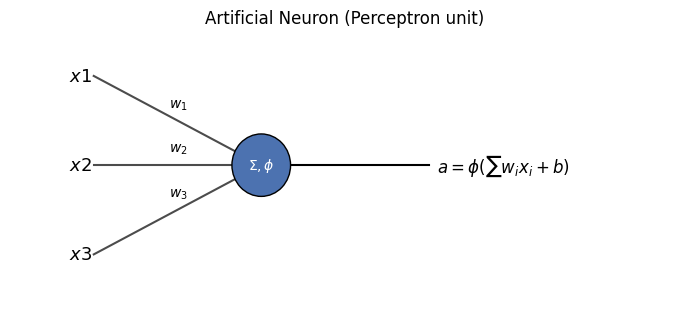

In [20]:
fig, ax = plt.subplots(figsize=(7,3.2))
ax.axis('off')
inputs = ['x1','x2','x3']
for i, name in enumerate(inputs):
    y = 2 - i
    ax.plot([0,2],[y,1],'k-',lw=1.5, alpha=0.7)
    ax.text(-0.3, y, f'${name}$', fontsize=13, va='center')
    ax.text(0.9, (y+1)/2+0.15, f'$w_{i+1}$', fontsize=10)
circle = plt.Circle((2,1), 0.35, color='#4C72B0', ec='black', zorder=3)
ax.add_patch(circle)
ax.text(2,1,r'$\Sigma,\phi$', ha='center', va='center', color='white', fontsize=10, zorder=4)
ax.plot([2.35,4],[1,1],'k-',lw=1.5)
ax.text(4.1,1,r'$a=\phi(\sum w_i x_i + b)$', fontsize=12, va='center')
ax.set_xlim(-1,7); ax.set_ylim(-0.5,2.5)
ax.set_title('Artificial Neuron (Perceptron unit)')
plt.tight_layout(); plt.show()

---
# Part B — The Perceptron (from scratch)

The simplest neural network: **one neuron**, a linear decision boundary. Let's build the classic Perceptron learning rule with NumPy, and test it on a **synthetic linearly-separable dataset** (`make_blobs`).


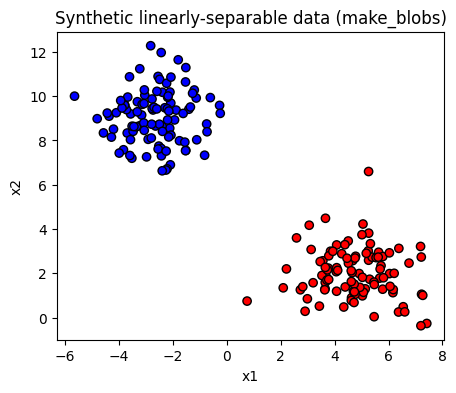

In [21]:
# Synthetic linearly-separable data
X_p, y_p = make_blobs(n_samples=200, centers=2, cluster_std=1.2, random_state=RANDOM_STATE)
y_p = np.where(y_p == 0, -1, 1)  # perceptron uses {-1, +1} labels

plt.figure(figsize=(5,4))
plt.scatter(X_p[:,0], X_p[:,1], c=y_p, cmap='bwr', edgecolor='k')
plt.title('Synthetic linearly-separable data (make_blobs)')
plt.xlabel('x1'); plt.ylabel('x2')
plt.show()

Training accuracy: 1.000


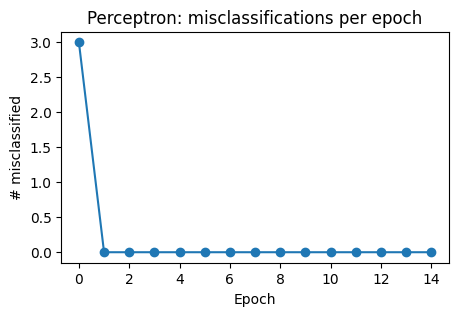

In [22]:
class Perceptron:
    def __init__(self, n_features, lr=0.01):
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.lr = lr

    def predict(self, X):
        return np.sign(X @ self.w + self.b)

    def fit(self, X, y, epochs=20):
        history = []
        for epoch in range(epochs):
            errors = 0
            for xi, yi in zip(X, y):
                pred = np.sign(xi @ self.w + self.b)
                if pred == 0:
                    pred = 1
                if pred != yi:
                    self.w += self.lr * yi * xi
                    self.b += self.lr * yi
                    errors += 1
            history.append(errors)
        return history

perc = Perceptron(n_features=2, lr=0.1)
history = perc.fit(X_p, y_p, epochs=15)

preds = perc.predict(X_p)
preds[preds==0] = 1
print(f"Training accuracy: {accuracy_score(y_p, preds):.3f}")

plt.figure(figsize=(5,3))
plt.plot(history, marker='o')
plt.title('Perceptron: misclassifications per epoch')
plt.xlabel('Epoch'); plt.ylabel('# misclassified')
plt.show()

**Takeaway:** a single perceptron can only learn **linearly separable** patterns. To model non-linear relationships we need to stack neurons into **layers** — a Multi-Layer Perceptron (MLP) — which is where Deep Learning begins.


---
# Part C — Components of a Neural Network

Every neural network is built from the same core pieces:

- **Layers** — input layer, one or more hidden layers, output layer.
- **Weights & biases** — learnable parameters that transform data as it flows through layers.
- **Activation functions** — inject non-linearity so the network can learn complex patterns.
- **Loss function** — measures how wrong the network's predictions are.
- **Forward propagation** — computing predictions layer by layer.
- **Backpropagation** — computing gradients of the loss w.r.t. every parameter, using the chain rule.
- **Optimizer** — uses those gradients to update weights (Part D).


## C.1 Activation Functions

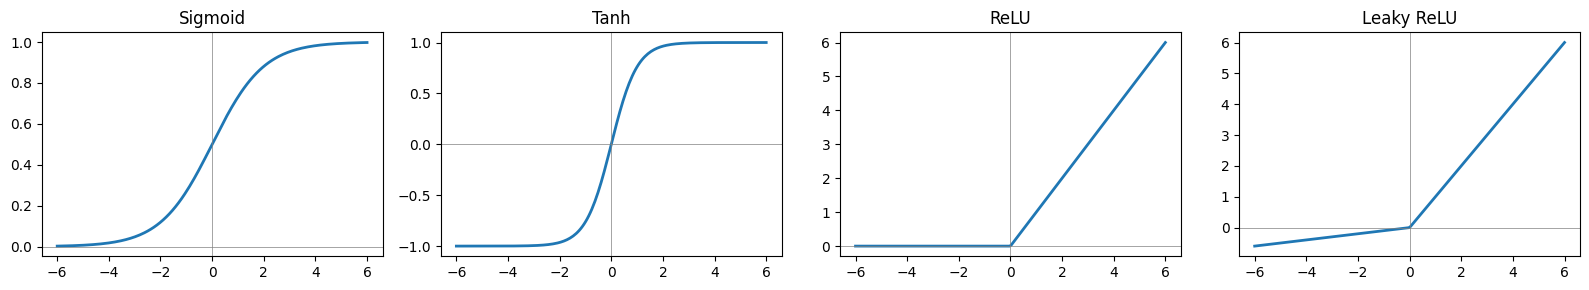

Softmax of [2.0, 1.0, 0.1] -> [0.659 0.242 0.099]  (sums to 1, used for multi-class output layers)


In [23]:
def sigmoid(z): return 1 / (1 + np.exp(-z))
def tanh(z): return np.tanh(z)
def relu(z): return np.maximum(0, z)
def leaky_relu(z, alpha=0.1): return np.where(z > 0, z, alpha * z)
def softmax(z):
    z = z - np.max(z, axis=-1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=-1, keepdims=True)

z = np.linspace(-6, 6, 200)
fns = {'Sigmoid': sigmoid(z), 'Tanh': tanh(z), 'ReLU': relu(z), 'Leaky ReLU': leaky_relu(z)}

fig, axes = plt.subplots(1, 4, figsize=(16,3))
for ax, (name, vals) in zip(axes, fns.items()):
    ax.plot(z, vals, lw=2)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(name)
plt.tight_layout(); plt.show()

print("Softmax of [2.0, 1.0, 0.1] ->", np.round(softmax(np.array([2.0, 1.0, 0.1])), 3), " (sums to 1, used for multi-class output layers)")

**When to use which:**
- **ReLU** — default choice for hidden layers (fast, avoids vanishing gradients for positive inputs).
- **Sigmoid** — output layer for binary classification (squashes to (0,1), interpretable as probability).
- **Softmax** — output layer for multi-class classification (probabilities across classes, sum to 1).
- **Tanh** — zero-centered alternative to sigmoid, sometimes used in RNNs.


## C.2 Loss Functions

In [24]:
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def binary_cross_entropy(y_true, y_pred, eps=1e-8):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def categorical_cross_entropy(y_true_onehot, y_pred, eps=1e-8):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(np.sum(y_true_onehot * np.log(y_pred), axis=1))

# Quick demo
y_true_reg = np.array([3.0, -1.0, 2.0])
y_pred_reg = np.array([2.5, -0.5, 2.2])
print("MSE (regression):", round(mse_loss(y_true_reg, y_pred_reg), 4))

y_true_bin = np.array([1, 0, 1, 1])
y_pred_bin = np.array([0.9, 0.2, 0.65, 0.4])
print("Binary Cross-Entropy:", round(binary_cross_entropy(y_true_bin, y_pred_bin), 4))

y_true_cat = np.array([[0,1,0],[1,0,0]])
y_pred_cat = np.array([[0.1,0.8,0.1],[0.7,0.2,0.1]])
print("Categorical Cross-Entropy:", round(categorical_cross_entropy(y_true_cat, y_pred_cat), 4))

MSE (regression): 0.18
Binary Cross-Entropy: 0.4189
Categorical Cross-Entropy: 0.2899


**Rule of thumb:** MSE for regression • Binary Cross-Entropy for 2-class classification • Categorical Cross-Entropy for multi-class classification.


## C.3 Forward Propagation & Backpropagation — from scratch

We'll build a tiny **2-layer MLP** (1 hidden layer) entirely with NumPy — no framework — on a **synthetic non-linear dataset** (`make_moons`, which a single perceptron *cannot* solve). This makes the mechanics of forward/backward pass completely transparent before we let PyTorch do it for us.


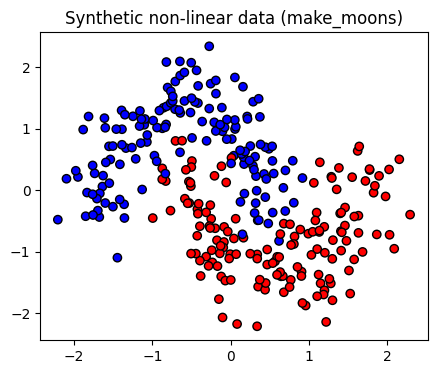

In [25]:
# Synthetic non-linear data
X, y = make_moons(n_samples=300, noise=0.2, random_state=RANDOM_STATE)
X = StandardScaler().fit_transform(X)
y = y.reshape(-1, 1)

plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='bwr', edgecolor='k')
plt.title('Synthetic non-linear data (make_moons)')
plt.show()

epoch    0 | loss 0.6787
epoch  500 | loss 0.3037
epoch 1000 | loss 0.2933
epoch 1500 | loss 0.2921
epoch 2000 | loss 0.2914
epoch 2500 | loss 0.2908

Final training accuracy: 0.877


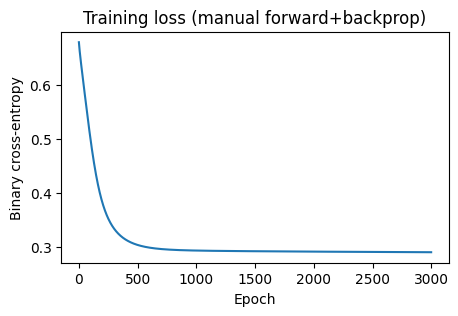

In [26]:
def sigmoid_deriv(a):
    return a * (1 - a)

# Initialize a 2 -> 8 -> 1 network
n_in, n_hidden, n_out = 2, 8, 1
rng = np.random.default_rng(RANDOM_STATE)
W1 = rng.normal(0, 0.5, size=(n_in, n_hidden))
b1 = np.zeros((1, n_hidden))
W2 = rng.normal(0, 0.5, size=(n_hidden, n_out))
b2 = np.zeros((1, n_out))

lr = 0.1
epochs = 3000
losses = []

for epoch in range(epochs):
    # ---- forward propagation ----
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)                       # final prediction

    loss = binary_cross_entropy(y, a2)
    losses.append(loss)

    # ---- backpropagation (chain rule) ----
    dz2 = (a2 - y) / y.shape[0]            # dL/dz2 for BCE + sigmoid combo
    dW2 = a1.T @ dz2
    db2 = dz2.sum(axis=0, keepdims=True)

    da1 = dz2 @ W2.T
    dz1 = da1 * sigmoid_deriv(a1)
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0, keepdims=True)

    # ---- gradient descent update ----
    W2 -= lr * dW2; b2 -= lr * db2
    W1 -= lr * dW1; b1 -= lr * db1

    if epoch % 500 == 0:
        print(f"epoch {epoch:4d} | loss {loss:.4f}")

preds = (a2 > 0.5).astype(int)
print(f"\nFinal training accuracy: {accuracy_score(y, preds):.3f}")

plt.figure(figsize=(5,3))
plt.plot(losses)
plt.title('Training loss (manual forward+backprop)')
plt.xlabel('Epoch'); plt.ylabel('Binary cross-entropy')
plt.show()

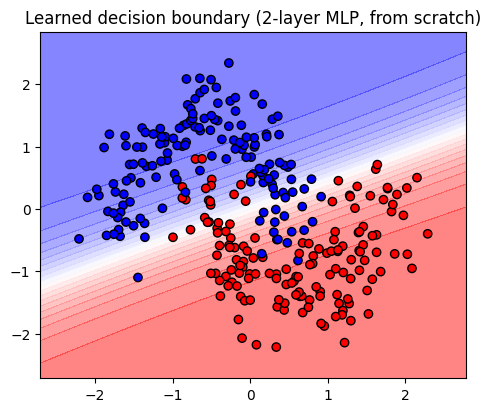

In [27]:
# Visualize the learned non-linear decision boundary
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 200),
                      np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
a1g = sigmoid(grid @ W1 + b1)
a2g = sigmoid(a1g @ W2 + b2).reshape(xx.shape)

plt.figure(figsize=(5.5,4.5))
plt.contourf(xx, yy, a2g, levels=20, cmap='bwr', alpha=0.5)
plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='bwr', edgecolor='k')
plt.title('Learned decision boundary (2-layer MLP, from scratch)')
plt.show()

**Key insight:** with a hidden layer + non-linear activation, the network learns a *curved* decision boundary — something a single perceptron structurally cannot do. This is the essence of "deep" learning: stacking layers to compose non-linear functions.


---
# Part D — Optimization Algorithms

Backprop gives us gradients; **optimizers** decide how to use them to update weights. We compare several optimizers on a synthetic elongated "valley" loss surface — a classic way to visualize why fancier optimizers were invented (plain gradient descent oscillates / converges slowly on ill-conditioned surfaces).


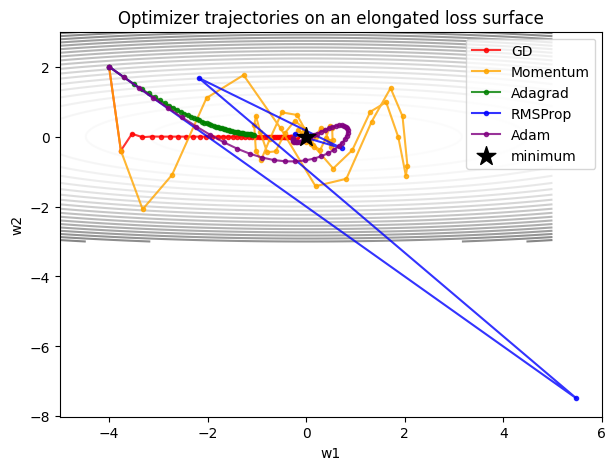

In [28]:
def loss_fn(w):
    x, yv = w
    return 0.1 * x**2 + 2 * yv**2          # elongated valley

def grad_fn(w):
    x, yv = w
    return np.array([0.2 * x, 4 * yv])

def run_optimizer(name, steps=50, lr=0.3):
    w = np.array([-4.0, 2.0])
    path = [w.copy()]
    v = np.zeros(2); s = np.zeros(2); m = np.zeros(2)
    beta1, beta2, eps = 0.9, 0.999, 1e-8
    for t in range(1, steps + 1):
        g = grad_fn(w)
        if name == 'GD':
            w = w - lr * g
        elif name == 'Momentum':
            v = 0.9 * v - lr * g
            w = w + v
        elif name == 'Adagrad':
            s += g**2
            w = w - lr * g / (np.sqrt(s) + eps)
        elif name == 'RMSProp':
            s = beta2 * s + (1 - beta2) * g**2
            w = w - lr * g / (np.sqrt(s) + eps)
        elif name == 'Adam':
            m = beta1 * m + (1 - beta1) * g
            s = beta2 * s + (1 - beta2) * g**2
            m_hat = m / (1 - beta1**t)
            s_hat = s / (1 - beta2**t)
            w = w - lr * m_hat / (np.sqrt(s_hat) + eps)
        path.append(w.copy())
    return np.array(path)

xx, yy = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-3, 3, 200))
zz = 0.1 * xx**2 + 2 * yy**2

fig, ax = plt.subplots(figsize=(7,5))
ax.contour(xx, yy, zz, levels=20, cmap='Greys', alpha=0.5)
for name, color in zip(['GD','Momentum','Adagrad','RMSProp','Adam'],
                        ['red','orange','green','blue','purple']):
    path = run_optimizer(name)
    ax.plot(path[:,0], path[:,1], marker='.', label=name, color=color, alpha=0.8)
ax.scatter([0],[0], marker='*', s=200, color='black', zorder=5, label='minimum')
ax.legend(); ax.set_title('Optimizer trajectories on an elongated loss surface')
ax.set_xlabel('w1'); ax.set_ylabel('w2')
plt.show()

**Observations you can point out live:**
- **Vanilla GD** overshoots along the steep axis and moves slowly along the flat one.
- **Momentum** smooths the path by accumulating velocity, reducing oscillation.
- **Adagrad** slows down aggressively over time as it accumulates squared gradients (can stall on long training runs).
- **RMSProp** fixes Adagrad's stalling issue with an exponential moving average of squared gradients.
- **Adam** combines momentum + RMSProp-style adaptive learning rates — usually the strongest default in practice.

### Effect of learning rate


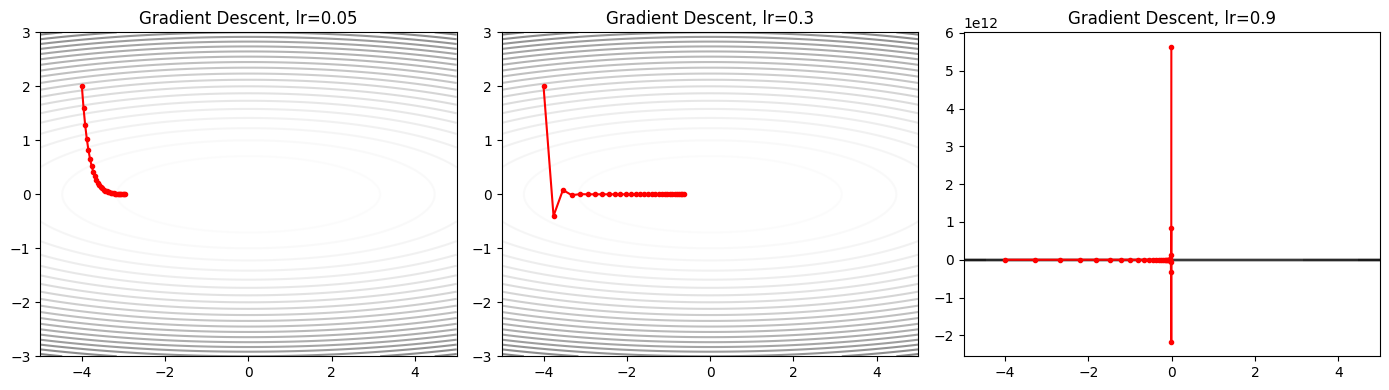

Too small -> slow convergence. Too large -> overshoot/divergence. Right in between -> efficient descent.


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, lr in zip(axes, [0.05, 0.3, 0.9]):
    ax.contour(xx, yy, zz, levels=20, cmap='Greys', alpha=0.5)
    path = run_optimizer('GD', steps=30, lr=lr)
    ax.plot(path[:,0], path[:,1], marker='.', color='red')
    ax.set_title(f'Gradient Descent, lr={lr}')
plt.tight_layout(); plt.show()
print("Too small -> slow convergence. Too large -> overshoot/divergence. Right in between -> efficient descent.")

---
# Part E — Building Neural Networks with PyTorch

Now that the mechanics are clear, we let a framework handle autograd and optimization. PyTorch's `nn.Module` + `autograd` + `optim` replace the manual forward/backward code from Part C with a few lines.


epoch   0 | loss 0.6955
epoch  40 | loss 0.1175
epoch  80 | loss 0.0047
epoch 120 | loss 0.0021
epoch 160 | loss 0.0013

Test accuracy: 0.988


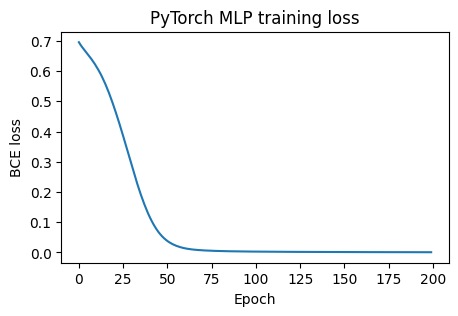

In [30]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)

# Synthetic dataset: two interleaving circles (another non-linear pattern)
Xc, yc = make_circles(n_samples=400, noise=0.1, factor=0.4, random_state=RANDOM_STATE)
Xc = StandardScaler().fit_transform(Xc)
Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.2, random_state=RANDOM_STATE)

Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
ytr_t = torch.tensor(ytr, dtype=torch.float32).unsqueeze(1)
Xte_t = torch.tensor(Xte, dtype=torch.float32)
yte_t = torch.tensor(yte, dtype=torch.float32).unsqueeze(1)

model = MLP(in_dim=2, hidden_dim=16, out_dim=1)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

train_losses = []
for epoch in range(200):
    optimizer.zero_grad()
    logits = model(Xtr_t)
    loss = criterion(logits, ytr_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    if epoch % 40 == 0:
        print(f"epoch {epoch:3d} | loss {loss.item():.4f}")

model.eval()
with torch.no_grad():
    test_preds = (torch.sigmoid(model(Xte_t)) > 0.5).float()
    test_acc = (test_preds.eq(yte_t)).float().mean().item()
print(f"\nTest accuracy: {test_acc:.3f}")

plt.figure(figsize=(5,3))
plt.plot(train_losses)
plt.title('PyTorch MLP training loss'); plt.xlabel('Epoch'); plt.ylabel('BCE loss')
plt.show()

**What PyTorch gave us for free:**
- `nn.Linear` — weights & biases management
- `autograd` — automatic backpropagation (`loss.backward()`)
- `optim.Adam` — a production-grade optimizer implementation
- GPU support — just call `.to('cuda')` on model & tensors

This is exactly the same math as Part C, but it scales to networks with millions of parameters.


---
# 🛠️ Project 1 — Symptom-Based Disease Predictor (Feedforward NN)

Inspired by the *"Medical Diagnoser"* project. Instead of a real patient dataset (privacy-sensitive & hard to source), we **synthesize** a symptom→disease dataset with clear, learnable patterns, then train a feedforward neural network to predict the disease from a symptom vector.

**Pipeline:** synthetic data generation → preprocessing → train/test split → PyTorch feedforward network → training → evaluation → prediction on a new "patient".


In [31]:
# --- Synthetic symptom-disease dataset generation ---
rng = np.random.default_rng(RANDOM_STATE)

diseases = ['Flu', 'Diabetes', 'Migraine', 'Allergy']
symptoms = ['fever', 'fatigue', 'headache', 'thirst', 'frequent_urination',
            'nausea', 'light_sensitivity', 'sneezing', 'itchy_eyes', 'cough']

# Each disease has a characteristic symptom profile (probability of each symptom appearing)
profiles = {
    'Flu':       [0.9, 0.7, 0.3, 0.05, 0.05, 0.3, 0.05, 0.4, 0.05, 0.8],
    'Diabetes':  [0.1, 0.8, 0.2, 0.9, 0.85, 0.3, 0.05, 0.05, 0.05, 0.05],
    'Migraine':  [0.1, 0.5, 0.9, 0.05, 0.05, 0.4, 0.85, 0.05, 0.05, 0.05],
    'Allergy':   [0.05, 0.3, 0.1, 0.05, 0.05, 0.1, 0.1, 0.9, 0.85, 0.3],
}

n_per_class = 250
X_rows, y_rows = [], []
for label, disease in enumerate(diseases):
    probs = np.array(profiles[disease])
    for _ in range(n_per_class):
        # sample binary symptom vector with a bit of random flip noise
        sample = (rng.random(len(symptoms)) < probs).astype(float)
        flip_mask = rng.random(len(symptoms)) < 0.05
        sample[flip_mask] = 1 - sample[flip_mask]
        X_rows.append(sample)
        y_rows.append(label)

X_med = np.array(X_rows)
y_med = np.array(y_rows)

print("Dataset shape:", X_med.shape, "| classes:", diseases)
import pandas as pd
df_preview = pd.DataFrame(X_med[:5], columns=symptoms)
df_preview['disease'] = [diseases[i] for i in y_med[:5]]
df_preview

Dataset shape: (1000, 10) | classes: ['Flu', 'Diabetes', 'Migraine', 'Allergy']


,fever,fatigue,headache,thirst,frequent_urination,nausea,light_sensitivity,sneezing,itchy_eyes,cough,disease
0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Flu
1,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,Flu
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,Flu
3,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,Flu
4,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,Flu


epoch   0 | loss 1.4667
epoch  30 | loss 0.2791
epoch  60 | loss 0.2164
epoch  90 | loss 0.1876
epoch 120 | loss 0.1756


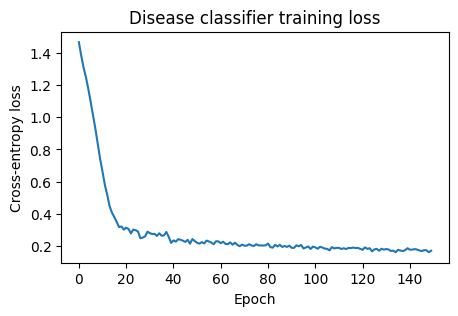

In [32]:
# --- Preprocess & split ---
Xtr, Xte, ytr, yte = train_test_split(X_med, y_med, test_size=0.2, stratify=y_med, random_state=RANDOM_STATE)
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)

Xtr_t = torch.tensor(Xtr_s, dtype=torch.float32)
ytr_t = torch.tensor(ytr, dtype=torch.long)
Xte_t = torch.tensor(Xte_s, dtype=torch.float32)
yte_t = torch.tensor(yte, dtype=torch.long)

class DiseaseClassifier(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_classes)
        )
    def forward(self, x):
        return self.net(x)

med_model = DiseaseClassifier(in_dim=X_med.shape[1], n_classes=len(diseases))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(med_model.parameters(), lr=0.01)

losses = []
for epoch in range(150):
    optimizer.zero_grad()
    logits = med_model(Xtr_t)
    loss = criterion(logits, ytr_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 30 == 0:
        print(f"epoch {epoch:3d} | loss {loss.item():.4f}")

plt.figure(figsize=(5,3))
plt.plot(losses); plt.title('Disease classifier training loss')
plt.xlabel('Epoch'); plt.ylabel('Cross-entropy loss'); plt.show()

Test accuracy: 0.930



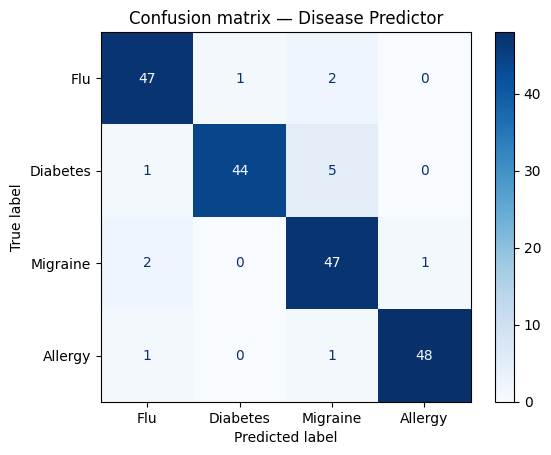

In [33]:
# --- Evaluate ---
med_model.eval()
with torch.no_grad():
    test_logits = med_model(Xte_t)
    test_preds = test_logits.argmax(dim=1).numpy()

acc = accuracy_score(yte, test_preds)
print(f"Test accuracy: {acc:.3f}\n")

cm = confusion_matrix(yte, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=diseases)
disp.plot(cmap='Blues')
plt.title('Confusion matrix — Disease Predictor')
plt.show()

In [34]:
# --- Predict on a brand-new synthetic patient ---
new_patient = {
    'fever': 0, 'fatigue': 1, 'headache': 0, 'thirst': 1, 'frequent_urination': 1,
    'nausea': 0, 'light_sensitivity': 0, 'sneezing': 0, 'itchy_eyes': 0, 'cough': 0
}
x_new = np.array([[new_patient[s] for s in symptoms]])
x_new_s = scaler.transform(x_new)
x_new_t = torch.tensor(x_new_s, dtype=torch.float32)

med_model.eval()
with torch.no_grad():
    probs = torch.softmax(med_model(x_new_t), dim=1).numpy()[0]

for disease, p in sorted(zip(diseases, probs), key=lambda t: -t[1]):
    print(f"{disease:10s}: {p*100:5.1f}%")
print(f"\nPredicted diagnosis: {diseases[int(np.argmax(probs))]}")

Diabetes  : 100.0%
Migraine  :   0.0%
Allergy   :   0.0%
Flu       :   0.0%

Predicted diagnosis: Diabetes


---
# 🛠️ Project 2 — Wine Type Classifier (Feedforward NN + full pipeline)

Inspired by the *"Prediction of Wine Type"* project. We synthesize chemical/sensory measurements (acidity, sugar, alcohol %, etc.) for three wine types with distinct, overlapping-but-separable statistical profiles — a good showcase for a slightly deeper network with **batch normalization**.


Wine dataset shape: (900, 6)


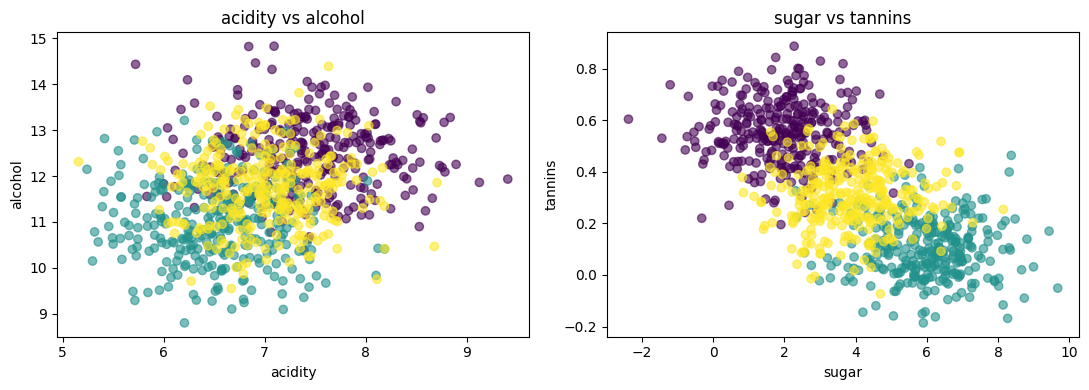

In [35]:
# --- Synthetic wine feature generation ---
rng = np.random.default_rng(RANDOM_STATE)

wine_types = ['Red', 'White', 'Rosé']
feature_names = ['acidity', 'sugar', 'alcohol', 'tannins', 'sulphates', 'density']

# mean feature vector per wine type + shared covariance-like noise
means = {
    'Red':   [7.5, 2.0, 12.5, 0.55, 0.65, 0.996],
    'White': [6.5, 6.0, 11.0, 0.10, 0.40, 0.993],
    'Rosé':  [7.0, 4.0, 11.8, 0.30, 0.50, 0.994],
}
stds = [0.6, 1.2, 0.8, 0.12, 0.10, 0.002]

n_per_class = 300
rows, labels = [], []
for label, wt in enumerate(wine_types):
    m = np.array(means[wt])
    s = np.array(stds)
    samples = rng.normal(loc=m, scale=s, size=(n_per_class, len(feature_names)))
    rows.append(samples)
    labels.extend([label]*n_per_class)

X_wine = np.vstack(rows)
y_wine = np.array(labels)
print("Wine dataset shape:", X_wine.shape)

fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].scatter(X_wine[:,0], X_wine[:,2], c=y_wine, cmap='viridis', alpha=0.6)
axes[0].set_xlabel('acidity'); axes[0].set_ylabel('alcohol'); axes[0].set_title('acidity vs alcohol')
axes[1].scatter(X_wine[:,1], X_wine[:,3], c=y_wine, cmap='viridis', alpha=0.6)
axes[1].set_xlabel('sugar'); axes[1].set_ylabel('tannins'); axes[1].set_title('sugar vs tannins')
plt.tight_layout(); plt.show()

epoch   0 | loss 1.0637 | test acc 0.800
epoch  20 | loss 0.1825 | test acc 0.906
epoch  40 | loss 0.1581 | test acc 0.917
epoch  60 | loss 0.1307 | test acc 0.894
epoch  80 | loss 0.1027 | test acc 0.894
epoch 100 | loss 0.0629 | test acc 0.889


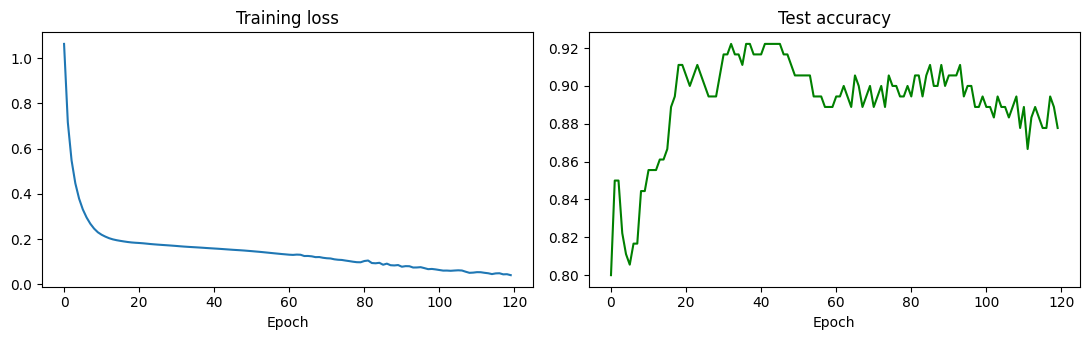

In [36]:
# --- Preprocess & split ---
Xtr, Xte, ytr, yte = train_test_split(X_wine, y_wine, test_size=0.2, stratify=y_wine, random_state=RANDOM_STATE)
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)

Xtr_t = torch.tensor(Xtr_s, dtype=torch.float32)
ytr_t = torch.tensor(ytr, dtype=torch.long)
Xte_t = torch.tensor(Xte_s, dtype=torch.float32)
yte_t = torch.tensor(yte, dtype=torch.long)

class WineNet(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=24):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_classes)
        )
    def forward(self, x):
        return self.net(x)

wine_model = WineNet(in_dim=X_wine.shape[1], n_classes=len(wine_types))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(wine_model.parameters(), lr=0.02)

train_losses, test_accs = [], []
for epoch in range(120):
    wine_model.train()
    optimizer.zero_grad()
    logits = wine_model(Xtr_t)
    loss = criterion(logits, ytr_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    wine_model.eval()
    with torch.no_grad():
        test_preds = wine_model(Xte_t).argmax(dim=1)
        test_accs.append((test_preds == yte_t).float().mean().item())

    if epoch % 20 == 0:
        print(f"epoch {epoch:3d} | loss {loss.item():.4f} | test acc {test_accs[-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11,3.5))
axes[0].plot(train_losses); axes[0].set_title('Training loss'); axes[0].set_xlabel('Epoch')
axes[1].plot(test_accs, color='green'); axes[1].set_title('Test accuracy'); axes[1].set_xlabel('Epoch')
plt.tight_layout(); plt.show()

Final test accuracy: 0.878



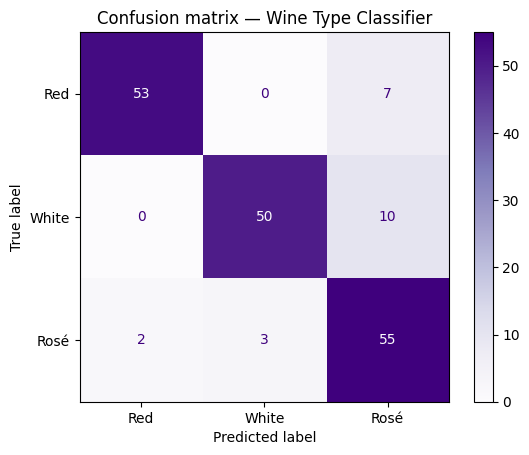

In [37]:
wine_model.eval()
with torch.no_grad():
    final_preds = wine_model(Xte_t).argmax(dim=1).numpy()

print(f"Final test accuracy: {accuracy_score(yte, final_preds):.3f}\n")
cm = confusion_matrix(yte, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine_types)
disp.plot(cmap='Purples')
plt.title('Confusion matrix — Wine Type Classifier')
plt.show()

---
# ✅ Recap — What we covered in Notebook 1

- What deep learning is and why it works now
- The artificial neuron & the Perceptron, and its limits
- Layers, weights/biases, activation functions, loss functions
- Forward propagation & backpropagation, implemented from scratch
- Gradient Descent and its variants: SGD, Momentum, Adagrad, RMSProp, Adam
- Building & training MLPs in PyTorch
- Two end-to-end projects: a disease predictor and a wine classifier

# ➡️ Coming up in Notebook 2

- Convolutional Neural Networks (CNNs) — padding, pooling, LeNet/AlexNet/VGG/ResNet ideas — with a synthetic image classification project
- Recurrent Neural Networks — RNN, LSTM, GRU — with a synthetic sequence/sentiment project
- Generative Models — Autoencoders & GANs on synthetic data
- A short intro to Deep Reinforcement Learning
